In [1]:
# Importing all the necessary libraries
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.coordinates import match_coordinates_sky
import math as math
from astropy.io import fits
from astropy.table import Table
import os
import seaborn as sns
from IPython.display import clear_output
import astropy.units as u
from sklearn.neighbors import KernelDensity,KNeighborsClassifier
import os
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler, Normalizer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, confusion_matrix, matthews_corrcoef, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, RandomizedSearchCV, GridSearchCV, StratifiedKFold, train_test_split
import pickle
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.cluster import KMeans
import subprocess
import joblib
import requests
from PIL import Image
import matplotlib.patches as patches
from sklearn.preprocessing import StandardScaler, RobustScaler, Normalizer
from collections import Counter
from astropy.visualization.wcsaxes import SphericalCircle
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor


pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", None)

SEED = 333
np.random.seed(SEED)

In [3]:
from auxiliar_astro.constants import *
from auxiliar_astro.data_processing import *
from auxiliar_astro.image_utils import *

In [ ]:
main_columns = ["RA", "DEC"] + mags_petro_c + mags_auto_c + FWHM_IMAGE + morphology + positions + flags + colors_r + Mg

columns_not_important = mags_petro+mags_auto+mags_aper_6+mags_aper_3+mags_iso+mags_e_iso+mags_e_aper_3+flux_auto+flux_iso+flux_petro+flux_err_auto+flux_err_iso+flux_aper_3+flux_aper_6+flux_err_auto+flux_err_iso+flux_err_petro+flux_err_aper_3+flux_err_aper_6+FWHM_WORLD+class_stars+isoarea_world+isoarea_image+flux_max+snr_win+treshold+mu_treshold+mu_max+background


# Paths originais
path_run1_original = fr"/work1/pierre/Faculdade_teiu/Dados/fornax/runs_rodrigo/arqs_origins/run1.fits"
path_UCDs_classicas_fornax = fr"/work1/pierre/Faculdade_teiu/Dados/UCDs/UCDs_classicas_fornax.fits"

# Background confirmed  
path_background_objects = fr"/work1/pierre/Faculdade_teiu/Dados/fornax/FDS_BACKGROUND.fits"

#####################


path_run1_correct_main = fr"/work1/pierre/Faculdade_teiu/run1_correct_main.parquet"
# run1_correct_main = pd.read_parquet(path_run1_correct_main)


# path_run1_correct_gaiadr3_vacs_lili_specz = fr"/work1/pierre/Faculdade_teiu/run1_correct_gaiadr3_vacs_lili_specz.parquet"
# run1_correct_gaiadr3_vacs_lili_specz = pd.read_parquet(path_run1_correct_gaiadr3_vacs_lili_specz)

run1_correct_gaiadr3_vacs_lili_specz_photoz = pd.read_parquet(fr"/work1/pierre/Faculdade_teiu/run1_correct_specz_photoz.parquet")

# Rodrigo photo_z

In [4]:
data_test = pd.read_csv(fr"/work1/pierre/Faculdade_teiu/github_teiu/busca_halpha/candidatas_halpha.csv")
data_test

,ID_,Field,RA,DEC,X_IMAGE,Y_IMAGE,THETA_IMAGE,ERRTHETA_IMAGE,A_IMAGE,ERRA_IMAGE,B_IMAGE,ERRB_IMAGE,X_WORLD,Y_WORLD,THETA_WORLD,ERRTHETA_WORLD,A_WORLD,ERRA_WORLD,B_WORLD,ERRB_WORLD,ELONGATION,ELLIPTICITY,KRON_RADIUS,PETRO_RADIUS,e_U_AUTO,e_U_PETRO,e_U_APER_6,FLAGS_U,FWHM_IMAGE_U,FLUX_RADIUS_20_U,FLUX_RADIUS_50_U,FLUX_RADIUS_70_U,FLUX_RADIUS_90_U,e_F378_AUTO,e_F378_PETRO,e_F378_APER_6,FLAGS_F378,FWHM_IMAGE_F378,FLUX_RADIUS_20_F378,FLUX_RADIUS_50_F378,FLUX_RADIUS_70_F378,FLUX_RADIUS_90_F378,e_F395_AUTO,e_F395_PETRO,e_F395_APER_6,FLAGS_F395,FWHM_IMAGE_F395,FLUX_RADIUS_20_F395,FLUX_RADIUS_50_F395,FLUX_RADIUS_70_F395,FLUX_RADIUS_90_F395,e_F410_AUTO,e_F410_PETRO,e_F410_APER_6,FLAGS_F410,FWHM_IMAGE_F410,FLUX_RADIUS_20_F410,FLUX_RADIUS_50_F410,FLUX_RADIUS_70_F410,FLUX_RADIUS_90_F410,e_F430_AUTO,e_F430_PETRO,e_F430_APER_6,FLAGS_F430,FWHM_IMAGE_F430,FLUX_RADIUS_20_F430,FLUX_RADIUS_50_F430,FLUX_RADIUS_70_F430,FLUX_RADIUS_90_F430,e_G_AUTO,e_G_PETRO,e_G_APER_6,FLAGS_G,FWHM_IMAGE_G,FLUX_RADIUS_20_G,FLUX_RADIUS_50_G,FLUX_RADIUS_70_G,FLUX_RADIUS_90_G,e_F515_AUTO,e_F515_PETRO,e_F515_APER_6,FLAGS_F515,FWHM_IMAGE_F515,FLUX_RADIUS_20_F515,FLUX_RADIUS_50_F515,FLUX_RADIUS_70_F515,FLUX_RADIUS_90_F515,e_R_AUTO,e_R_PETRO,e_R_APER_6,FLAGS_R,FWHM_IMAGE_R,FLUX_RADIUS_20_R,FLUX_RADIUS_50_R,FLUX_RADIUS_70_R,FLUX_RADIUS_90_R,e_F660_AUTO,e_F660_PETRO,e_F660_APER_6,FLAGS_F660,FWHM_IMAGE_F660,FLUX_RADIUS_20_F660,FLUX_RADIUS_50_F660,FLUX_RADIUS_70_F660,FLUX_RADIUS_90_F660,e_I_AUTO,e_I_PETRO,e_I_APER_6,FLAGS_I,FWHM_IMAGE_I,FLUX_RADIUS_20_I,FLUX_RADIUS_50_I,FLUX_RADIUS_70_I,FLUX_RADIUS_90_I,e_F861_AUTO,e_F861_PETRO,e_F861_APER_6,FLAGS_F861,FWHM_IMAGE_F861,FLUX_RADIUS_20_F861,FLUX_RADIUS_50_F861,FLUX_RADIUS_70_F861,FLUX_RADIUS_90_F861,e_Z_AUTO,e_Z_PETRO,e_Z_APER_6,FLAGS_Z,FWHM_IMAGE_Z,FLUX_RADIUS_20_Z,FLUX_RADIUS_50_Z,FLUX_RADIUS_70_Z,FLUX_RADIUS_90_Z,U_ext,F378_ext,F395_ext,F410_ext,F430_ext,G_ext,F515_ext,R_ext,F660_ext,I_ext,F861_ext,Z_ext,W1_ab_ext,W2_ab_ext,Ypmag_ext,Jpmag_ext,Hpmag_ext,Kspmag_ext,FUVmag_ext,NUVmag_ext,U_PETRO_c,U_AUTO_c,U_APER_3_c,U_APER_6_c,U_ISO_c,F378_PETRO_c,F378_AUTO_c,F378_APER_3_c,F378_APER_6_c,F378_ISO_c,F395_PETRO_c,F395_AUTO_c,F395_APER_3_c,F395_APER_6_c,F395_ISO_c,F410_PETRO_c,F410_AUTO_c,F410_APER_3_c,F410_APER_6_c,F410_ISO_c,F430_PETRO_c,F430_AUTO_c,F430_APER_3_c,F430_APER_6_c,F430_ISO_c,G_PETRO_c,G_AUTO_c,G_APER_3_c,G_APER_6_c,G_ISO_c,F515_PETRO_c,F515_AUTO_c,F515_APER_3_c,F515_APER_6_c,F515_ISO_c,R_PETRO_c,R_AUTO_c,R_APER_3_c,R_APER_6_c,R_ISO_c,F660_PETRO_c,F660_AUTO_c,F660_APER_3_c,F660_APER_6_c,F660_ISO_c,I_PETRO_c,I_AUTO_c,I_APER_3_c,I_APER_6_c,I_ISO_c,F861_PETRO_c,F861_AUTO_c,F861_APER_3_c,F861_APER_6_c,F861_ISO_c,Z_PETRO_c,Z_AUTO_c,Z_APER_3_c,Z_APER_6_c,Z_ISO_c,PQSO,PGal,PSS,PROB_STAR,PROB_GAL,PROB_QSO,FWHM_R_n,FWHM_U_n,FWHM_G_n,FWHM_I_n,FWHM_Z_n,FWHM_F378_n,FWHM_F395_n,FWHM_F410_n,FWHM_F430_n,FWHM_F515_n,FWHM_F660_n,FWHM_F861_n,z,e_z,zml,sigma_68,odds,pdf_num_peaks,pdf_peak_height,photo_z,U-F378,U-F395,U-F410,U-F430,U-G,U-F515,U-R,U-F660,U-I,U-F861,U-Z,F378-F395,F378-F410,F378-F430,F378-G,F378-F515,F378-R,F378-F660,F378-I,F378-F861,F378-Z,F395-F410,F395-F430,F395-G,F395-F515,F395-R,F395-F660,F395-I,F395-F861,F395-Z,F410-F430,F410-G,F410-F515,F410-R,F410-F660,F410-I,F410-F861,F410-Z,F430-G,F430-F515,F430-R,F430-F660,F430-I,F430-F861,F430-Z,G-F515,G-R,G-F660,G-I,G-F861,G-Z,F515-R,F515-F660,F515-I,F515-F861,F515-Z,R-F660,R-I,R-F861,R-Z,F660-I,F660-F861,F660-Z,I-F861,I-Z,F861-Z,predict_p,predict,flux_radius_90_70_r,flux_radius_90_50_r,flux_radius_90_20_r,flux_radius_70_50_r,flux_radius_70_20_r,flux_radius_50_20_r,cor_660,cor_861
0,iDR4_FORNAX_RUN1_SPLUS-s24s31.13222,SPLUS-s24s31,47.189765,-30.853485,5342.07800,5820.2173,-22.630087,-23.336325,1.564469,0.098791,1.175024,0.073727,47.189765,-30.853485,22.640783,23.346846,0.000239,0.000015,0.000180,0.000011,1.331436,0.248931,5.463196,6.599999,0.612023,0.835937,0.375846,0,8.109181,0.935993,1.559927,2.520415,3.377866,0.502719,0.564981,0.455558,0,8.109181,1.068350,2.137077,3.084061,6

Debug: Encontrados 0 erros válidos de 12 total


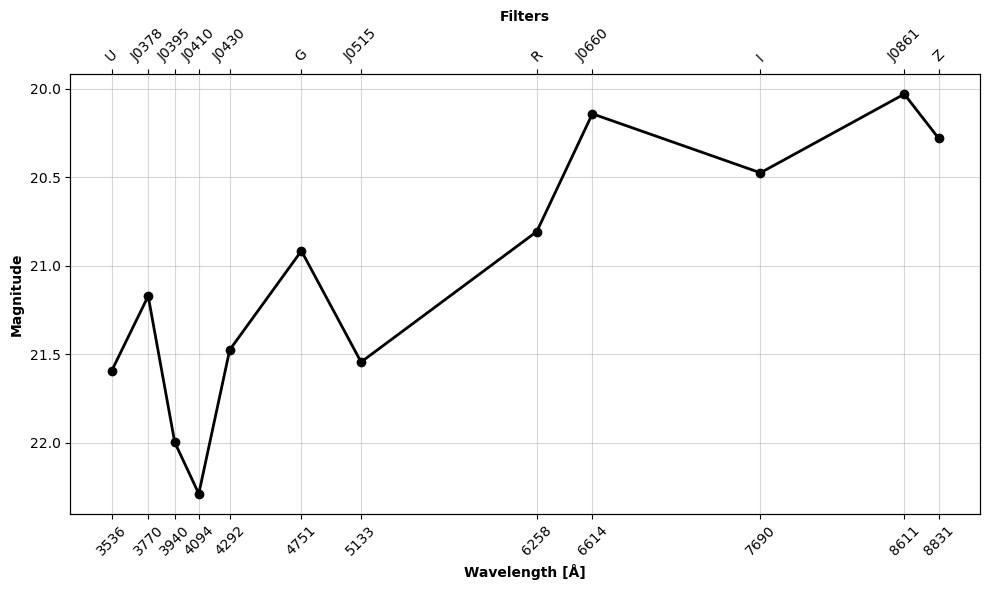

In [5]:
data_test_1 = data_test.iloc[0]

# data_test_1["B_mag"] = 18
# data_test_1["V_mag"] = 17.5
# data_test_1["R_mag"] = 17.2
# data_test_1["I_mag"] = 16.8

custom_filters = ['U', 'J0378', 'J0395', 'J0410', 'J0430', 'G', 'J0515', 'R', 'J0660', 'I', 'J0861', 'Z', 'B', 'V', 'R', 'I']
custom_wavelengths = [3536, 3770, 3940, 4094, 4292, 4751, 5133, 6258, 6614, 7690, 8611, 8831, 4400, 5500, 6400, 8000]



column_map = {
    'U_APER_6_c': 'U',
    'F378_APER_6_c': 'J0378',
    'F395_APER_6_c': 'J0395',
    'F410_APER_6_c': 'J0410',
    'F430_APER_6_c': 'J0430',
    'G_APER_6_c': 'G',
    'F515_APER_6_c': 'J0515',
    'R_APER_6_c': 'R',
    'F660_APER_6_c': 'J0660',
    'I_APER_6_c': 'I',
    'F861_APER_6_c': 'J0861',
    'Z_APER_6_c': 'Z'
}

figa, ax1a, ax2x = draw_photospec(data_test_1, column_map=column_map)

Aviso: Coluna 'B_mag' não encontrada no DataFrame
Aviso: Coluna 'V_mag' não encontrada no DataFrame
Aviso: Coluna 'R_mag' não encontrada no DataFrame
Aviso: Coluna 'I_mag' não encontrada no DataFrame
Debug: Encontrados 0 erros válidos de 12 total
Aviso: Coluna 'B_mag' não encontrada no DataFrame
Aviso: Coluna 'V_mag' não encontrada no DataFrame
Aviso: Coluna 'R_mag' não encontrada no DataFrame
Aviso: Coluna 'I_mag' não encontrada no DataFrame
Debug: Encontrados 0 erros válidos de 12 total
Aviso: Coluna 'B_mag' não encontrada no DataFrame
Aviso: Coluna 'V_mag' não encontrada no DataFrame
Aviso: Coluna 'R_mag' não encontrada no DataFrame
Aviso: Coluna 'I_mag' não encontrada no DataFrame
Debug: Encontrados 0 erros válidos de 12 total


<Figure size 1400x800 with 0 Axes>

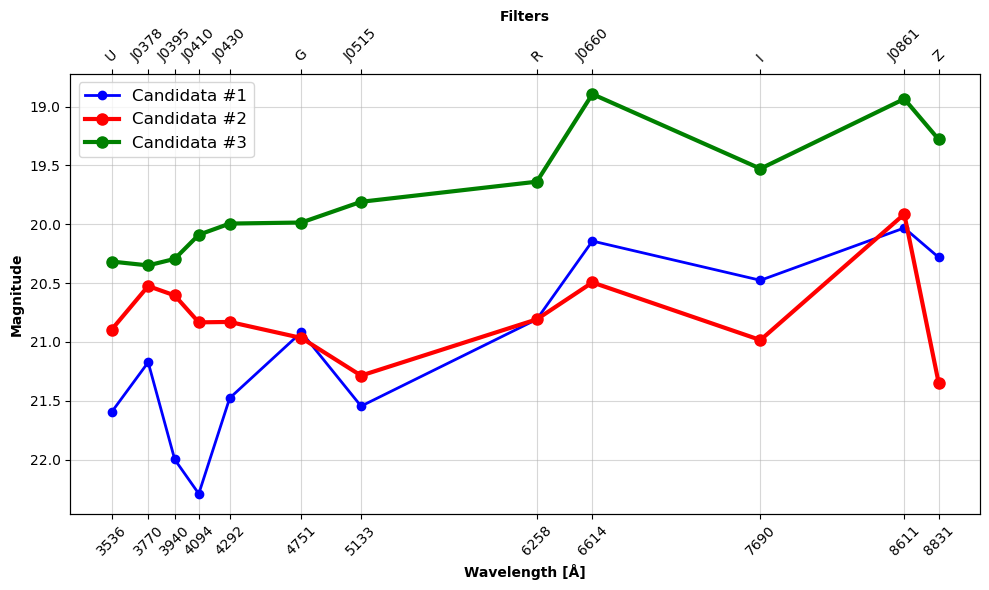

In [36]:
# Versão mais simples usando plt.figure() atual
plt.figure(figsize=(14, 8))

indices_objetos = [0, 1, 2]
cores = ['blue', 'red', 'green']
labels = ['Candidata #1', 'Candidata #2', 'Candidata #3']

for i, (obj_idx, cor, label) in enumerate(zip(indices_objetos, cores, labels)):
    # Usar show_plot=False para não mostrar individualmente
    fig_temp, ax1_temp, ax2_temp = draw_photospec(
        data_test, 
        column_map=column_map,
        object_index=obj_idx,
        color=cor,
        aperture_name=label,
        show_plot=False
    )
    
    if i == 0:
        # Guardar a primeira figura
        main_fig = fig_temp
        main_ax1 = ax1_temp
        main_ax2 = ax2_temp
    else:
        # Adicionar linhas das outras figuras à primeira
        for line in ax1_temp.get_lines():
            main_ax1.plot(line.get_xdata(), line.get_ydata(), 
                         color=cor, marker='o', label=label,
                         markersize=8, linewidth=3, linestyle='-')
        plt.close(fig_temp)  # Fechar figura extra

# Ajustar legenda e mostrar
main_ax1.legend(fontsize=12)
# main_fig.suptitle('Comparação de Fotoespectros - Candidatas H-alpha', fontweight='bold', fontsize=16)
plt.show()

In [ ]:
# %% Configuración inicial
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
import joblib
import os

# Configuración global
plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})
np.random.seed(42)

# Parámetros principales
ARCHIVO_DATOS = "datos.csv"
DIR_MODELOS = "modelos"
DIR_FIGURAS = "figuras"
Z_MAX = 0.5
N_JOBS = -1

os.makedirs(DIR_MODELOS, exist_ok=True)
os.makedirs(DIR_FIGURAS, exist_ok=True)

def cargar_datos(archivo):
    """Carga y limpia los datos de múltiples surveys"""
    mapeo_columnas = {
        # S-PLUS
        'U_AUTO_1': 'U', 'F378_AUTO_1': 'F378', 'F395_AUTO_1': 'F395',
        'F410_AUTO_1': 'F410', 'F430_AUTO_1': 'F430', 'G_AUTO_1': 'G',
        'F515_AUTO_1': 'F515', 'R_AUTO_1': 'R', 'F660_AUTO_1': 'F660',
        'I_AUTO_1': 'I', 'F861_AUTO_1': 'F861', 'Z_AUTO_1': 'Z',
        # WISE
        'W1mag': 'W1', 'W2mag': 'W2', 'W3mag': 'W3', 'W4mag': 'W4',
        # 2MASS
        'Jmag': 'J', 'Hmag': 'H', 'Kmag': 'K',
        # GALEX
        'FUVmag': 'FUV', 'NUVmag': 'NUV'
    }
    
    df = pd.read_csv(archivo).rename(columns=mapeo_columnas)
    df.replace([99, np.nan, 'nan', '', 'NA'], -99, inplace=True)
    return df[df['redshift'] <= Z_MAX].reset_index(drop=True)

def calcular_caracteristicas(df):
    """Calcula magnitudes y colores entre todas las bandas"""
    bandas = [
        'FUV', 'NUV', 'U', 'F378', 'F395', 'F410', 'F430', 'G',
        'F515', 'R', 'F660', 'I', 'F861', 'Z', 'W1', 'W2', 'W3',
        'W4', 'J', 'H', 'K'
    ]
    
    nuevas_columnas = {}
    for i in range(len(bandas)):
        for j in range(i+1, len(bandas)):
            b1, b2 = bandas[i], bandas[j]
            mask = (df[b1] != -99) & (df[b2] != -99)
            nuevas_columnas[f"{b1}-{b2}"] = np.where(mask, df[b1] - df[b2], -99)
    
    return pd.concat([df, pd.DataFrame(nuevas_columnas)], axis=1), bandas + list(nuevas_columnas.keys())

# ===================== PREPROCESAMIENTO =====================
class PreprocesadorCompleto:
    """Pipeline completo de preprocesamiento"""
    def __init__(self, max_faltantes=0.3):
        self.max_faltantes = max_faltantes
        self.imputador = SimpleImputer(strategy='median')
        self.escalador = StandardScaler()
        self.caracteristicas_seleccionadas = []
        
    def fit_transform(self, X):
        # Selección de características
        faltantes = (X == -99).mean()
        self.caracteristicas_seleccionadas = faltantes[faltantes <= self.max_faltantes].index.tolist()
        X_filtrado = X[self.caracteristicas_seleccionadas].replace(-99, np.nan)
        
        # Transformaciones
        X_imputado = self.imputador.fit_transform(X_filtrado)
        return self.escalador.fit_transform(X_imputado)
    
    def transform(self, X):
        X_filtrado = X[self.caracteristicas_seleccionadas].replace(-99, np.nan)
        X_imputado = self.imputador.transform(X_filtrado)
        return self.escalador.transform(X_imputado)


def calcular_metricas(y_real, y_pred):
    """Calcula todas las métricas requeridas"""
    delta_z = y_pred - y_real
    factor = 1 + y_real
    
    # Scatter NMAD
    sigma_nmad = 1.48 * np.median(np.abs((delta_z - np.median(delta_z)) / factor))
    
    # Bias
    bias = np.median(delta_z)
    bias_norm = np.median(delta_z / factor)
    
    # Fracción de outliers
    outlier_frac = np.mean(np.abs(delta_z) / factor > 0.15)
    
    return {
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'MAE': mean_absolute_error(y_real, y_pred),
        'R²': r2_score(y_real, y_pred),
        'σ_NMAD': sigma_nmad,
        'Bias': bias,
        'Bias Normalizado': bias_norm,
        'Fracción Outliers': outlier_frac
    }

# %% --- ENTRENAMIENTO DEL MODELO ---
def entrenar_modelo():
    df = cargar_datos(ARCHIVO_DATOS)
    df, caracteristicas = calcular_caracteristicas(df)
    
    preprocesador = PreprocesadorCompleto(max_faltantes=0.3)
    X = preprocesador.fit_transform(df[caracteristicas])
    y = df['redshift'].values
    
    X_ent, X_prueba, y_ent, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = Pipeline([
        ('model', RandomForestRegressor(
            n_estimators=500,
            max_depth=20,
            min_samples_split=5,
            n_jobs=N_JOBS,
            random_state=42
        ))
    ])
    model.fit(X_ent, y_ent)
    
    # Guardar componentes
    joblib.dump({
        'modelo': model,
        'preprocesador': preprocesador,
        'X_prueba': X_prueba,
        'y_prueba': y_prueba
    }, os.path.join(DIR_MODELOS, 'mejor_modelo.joblib'))
    
    return model, preprocesador, X_prueba, y_prueba

# Ejecutar solo una vez para entrenar y guardar
if __name__ == "__main__":
    model, preprocesador, X_prueba, y_prueba = entrenar_modelo()


def visualizacion_final(y_real, y_pred, preprocesador, nombre_figura="resultado_final.png"):
    """Genera la visualización con todos los requisitos finales"""
    fig = plt.figure(figsize=(18, 18))
    gs = GridSpec(3, 2, width_ratios=[3, 1], height_ratios=[3, 1, 0.5], hspace=0.02)
    
    # Cálculos necesarios (sin cambios)
    residuos = y_pred - y_real
    factor = 1 + y_real
    residuos_norm = residuos / factor
    x_vals = np.linspace(0, Z_MAX, 100)
    y_upper_main = x_vals + 0.15*(1 + x_vals)
    y_lower_main = x_vals - 0.15*(1 + x_vals)
    y_upper_res = 0.15 * np.ones_like(x_vals)
    y_lower_res = -0.15 * np.ones_like(x_vals)
    densidad = gaussian_kde(np.vstack([y_real, y_pred]))(np.vstack([y_real, y_pred]))
    
    # Gráfico principal (zspec vs zphot)
    ax1 = fig.add_subplot(gs[0, 0])
    scatter = ax1.scatter(y_real, y_pred, c=densidad, cmap='coolwarm', alpha=0.7)
    ax1.plot([0, Z_MAX], [0, Z_MAX], 'k--', lw=2)
    ax1.fill_between(x_vals, y_upper_main, Z_MAX, color='red', alpha=0.1)
    ax1.fill_between(x_vals, 0, y_lower_main, color='red', alpha=0.1)
    ax1.set(xlim=(0, Z_MAX), ylim=(0, Z_MAX), aspect='equal',
           xlabel='z$_{spec}$', ylabel='z$_{phot}$')
    
    # Gráfico de residuales
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax2.scatter(y_real, residuos_norm, c=densidad, cmap='coolwarm', alpha=0.7)
    ax2.axhline(0, color='k', linestyle='--', lw=2)
    ax2.fill_between(x_vals, y_upper_res, 0.3, color='red', alpha=0.1)
    ax2.fill_between(x_vals, -0.3, y_lower_res, color='red', alpha=0.1)
    ax2.set(ylim=(-0.3, 0.3), 
           ylabel='(z$_{phot}$ - z$_{spec}$)/(1 + z$_{spec}$)', xlabel='z$_{spec}$')
    
    # Barra de color
    pos_ax1 = ax1.get_position()
    cax = fig.add_axes([pos_ax1.x0, pos_ax1.y1 + 0.03, pos_ax1.width, 0.02])  # Posición ajustada
    plt.colorbar(scatter, cax=cax, orientation='horizontal', label='Density', ticklocation='top')
    
    # Importancia de características
    ax3 = fig.add_subplot(gs[0, 1])
    importancias = pd.Series(model.named_steps['model'].feature_importances_,
                           index=preprocesador.caracteristicas_seleccionadas)
    top10 = importancias.nlargest(10).sort_values()
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, 10))
    top10.plot.barh(color=colors, ax=ax3)
    ax3.set(xlabel='Contribution', title='')
    
    # Métricas debajo del histograma
    ax4 = fig.add_subplot(gs[1, 1])
    metricas = calcular_metricas(y_real, y_pred)
    texto_metricas = "\n".join([f"{k}: {v:.4f}" for k, v in metricas.items()])
    ax4.text(0.5, 0.5, texto_metricas, ha='center', va='top', fontsize=18)
    ax4.axis('off')
    
    # Ajustes finales
    plt.subplots_adjust(top=0.9)  # Ajuste para la barra de color
    plt.savefig(os.path.join(DIR_FIGURAS, nombre_figura), dpi=300, bbox_inches='tight')
    plt.show()

# Cargar modelo y datos guardados
def cargar_datos_visualizacion():
    datos = joblib.load(os.path.join(DIR_MODELOS, 'mejor_modelo.joblib'))
    y_pred = datos['modelo'].predict(datos['X_prueba'])
    return datos['y_prueba'], y_pred, datos['preprocesador']

# Ejecutar para visualizar con el último modelo
y_real, y_pred, preprocesador = cargar_datos_visualizacion()
visualizacion_final(y_real, y_pred, preprocesador)

In [50]:
fornax_objects_ra_dec = fits_open(fr'fornax_objects_ra_dec.fits')

UCDs_fornax_path = fr"/work1/pierre/Faculdade_teiu/Dados/UCDs/UCDs_run1_properties.csv"
UCDs_fornax = pd.read_csv(UCDs_fornax_path)

UCDs_fornax = make_colors(UCDs_fornax, colors, mag_type='APER_6_c')

In [ ]:
run1_correct_specz_photozs_valid = run1_correct_specz_photozs.query(fr"z>=0")

# Salvar
run1_correct_specz_photozs_valid.to_parquet("run1_correct_gaiadr3_vacs_lili_specz_valid.parquet")

In [3]:
run1_correct_gaiadr3_vacs_lili_specz_valid = pd.read_parquet("run1_correct_gaiadr3_vacs_lili_specz_valid.parquet")